# Calcium Aluminosilicate Glass Simulation with Pedone PMMCS Potential
This notebook is designed to showcase the implementations of the pyiron_glass package for simulating multi-component glasses with classical interatomic potentials.
It will be further extended to include more complex simulations and analyses.


## Potential and Elements
Simulations implemented so far are based on the PMMCS interatomic potential from A. Pedone et.al., JPCB (2006), https://doi.org/10.1021/jp0611018.
The PMMCS potential makes use of 2-body MORSE interactions between oxygen and cations, electrostatic interactions based on scaled partial charges (i.e., O=-1.2, Na=0.6, Mg=1.2, Al=1.8) among all ions, and a repulsive short-range term. It was originally fitted to reproduce the experimental crystal structures and elastic constants of oxides, silicates, and aluminosilicates.

The supported elements in alphabetical order are:

Ag, Al, Ba, Be, Ca, Co, Cr, Cu, Er, Fe, Fe3, Gd, Ge, K, Li, Mg, Mn, Na, Nd, Ni, O, P, Sc, Si, Sn, Sr, Ti, Zn, Zr

The cations can be classified into three categories:
- Alkali: Li, Na, K
- Alkaline Earth: Be, Mg, Ca, Sr, Ba
- Transition/Other: Fe, Zn, Al, Ti, Zr, etc.

Typical compositions the potential can handle include:
- Silicate-based systems: SiO2, Al2O3-SiO2, Na2O-SiO2, etc.
- Phosphate-based systems: P2O5 with modifiers (Ca, Mg, Zn, etc.)
- Mixed network formers: SiO2-P2O5-Al2O3 systems


## Standard Melt-Quenching Protocol and Parameters
Simulation settings employed in the following simulations do not represent production run conditions and are rather for demonstration purposes. They can be adjusted based on the specific requirements of your simulation. The simulation workflow consists of the following steps:

0. Random structure generation based on composition, number of atoms and density. For fast simulations, a small number of atoms (e.g., 200) is used.
1. NVT: heating from 300 to 5000 K with a constant heating rate (here: on the order of 1-10 K/ps)
2. NVT: equilibration of the melt at 5000 K for 100 ps (NVT ensemble)
3. NVT: cooling with down to 300 K (again with 1-10 K/ps)
4. NpT: equilibration at 300 K to relax the stress
5. NVT: extended equilibration at 300 K to extract thermodynamic and structural properties

Typical simulation parameters are applied: lammps metal units, periodic boundary conditions, timestep of 1-2 fs. Other default parameters are hidden in the underlying lammps functions, such as temperature damping of 100 time units and pressure damping of 1000 time units. If desired, Langevin thermostat and barostat can be used by setting the corresponding options.


# Import of packages

In [1]:
from pyiron_base import job, Project

from pyiron_glass import (
    melt_quench_simulation as _melt_quench_simulation,
    generate_potential as _generate_potential,
    get_ase_structure as _get_ase_structure,
    get_structure_dict as _get_structure_dict,
)

from pyiron_glass.workflows.structural_analysis import (
    analyze_structure as _analyze_structure,
    plot_analysis_results_plotly,
)

analyze_structure = job(_analyze_structure)
melt_quench_simulation = job(_melt_quench_simulation)
generate_potential = job(_generate_potential)
get_ase_structure = job(_get_ase_structure)
get_structure_dict = job(_get_structure_dict)

# Example Melt-Quenching Simulation

In [2]:
# Definition of the pyiron project,
# generating an initial random structure
# and setting up the potential information
pr = Project("glass")
atoms_dict = get_structure_dict(
    composition="25CaO-25Al2O3-50SiO2",  #    comp = "20.2CaO-36.6Al2O3-43.2SiO2" this is in weight%,
    n_molecules=None,
    target_atoms=340,
    mode="molar",  # mode = "weight",
    density=None,
    min_distance=1.8,
    max_attempts_per_atom=10000,
    pyiron_project=pr,
)
structure = get_ase_structure(
    atoms_dict=atoms_dict,
    replicate=(1, 1, 1),
    pyiron_project=pr,
)
generated_potential = generate_potential(
    atoms_dict=atoms_dict,
    potential_type="pmmcs",
    pyiron_project=pr,
)

In [3]:
# Specification of the cpu parameters
ncpus = 4
server_kwargs = {"cores": ncpus}

# Specification of the melt-quenching parameters
delayed = melt_quench_simulation(
    structure=structure,
    potential=generated_potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    langevin=False,
    server_kwargs=server_kwargs,
    pyiron_project=pr,
)

# Set server settings
# delayed.server.queue = "big"
# delayed.server.cores = ncpus
# delayed.server.run_time = 1440

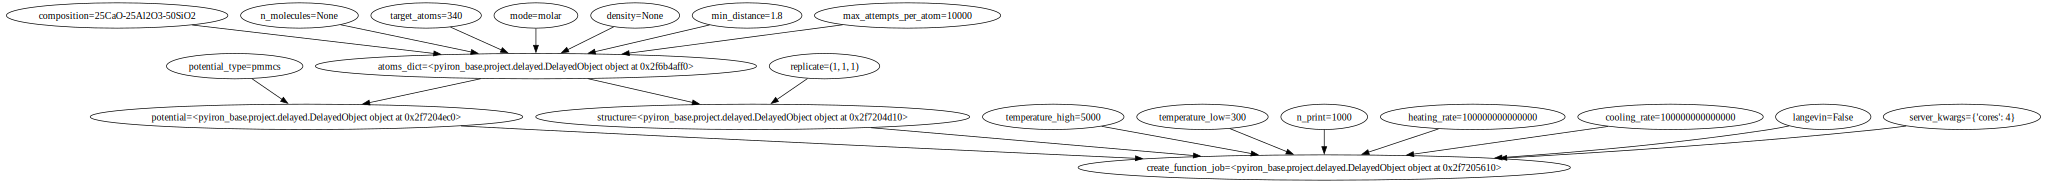

In [4]:
delayed.draw()

In [5]:
# Run the simulation and retrieve the results. Takes 5-10 minutes with the default testing parameters.
result = delayed.pull()

The job get_structure_dict_469449abd54fa92a8bc05881bc6d3249 was saved and received the ID: 160
The job get_ase_structure_4a2d52a77f1d4a591775065e8fccdb60 was saved and received the ID: 161
The job generate_potential_f0a2d90848bad278afee85f14ab625e7 was saved and received the ID: 162


/Users/jan/mambaforge/envs/pyiron/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)
/Users/jan/mambaforge/envs/pyiron/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/Users/jan/mambaforge/envs/pyiron/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(

The job melt_quench_simulation_2e868657f3a2c16f59acd0b8144efe37 was saved and received the ID: 163


/Users/jan/mambaforge/envs/pyiron/lib/python3.12/site-packages/h5io/_h5io.py:72: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(file_name, key=rootpath)
/Users/jan/mambaforge/envs/pyiron/lib/python3.12/site-packages/h5io/_h5io.py:78: PerformanceWarning: 
your performance may suffer as PyTables will pickle object types that it cannot
map directly to c-types [inferred_type->mixed,key->block0_values] [items->Index(['Name', 'Filename', 'Model', 'Species', 'Config'], dtype='object')]

  data.to_hdf(fname, key=rootpath)


In [6]:
structure_glass = result["structure"]
structure_glass

Atoms(symbols='Al52Ca26O210Si53', pbc=True, cell=[[16.21259183233507, 2.97820480400275e-15, 2.9782048040027505e-15], [-1.985469869335167e-15, 16.21259183233507, 2.97820480400275e-15], [-1.9854698693351665e-15, -1.985469869335167e-15, 16.21259183233507]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)

In [7]:
results_analysis = analyze_structure(atoms=structure_glass, pyiron_project=pr).pull()

The job analyze_structure_8a9ca5201adf1a63d38b036a47b2662e was saved and received the ID: 164


100%|███████████████████████████████████████| 366/366 [00:00<00:00, 2478.73it/s]


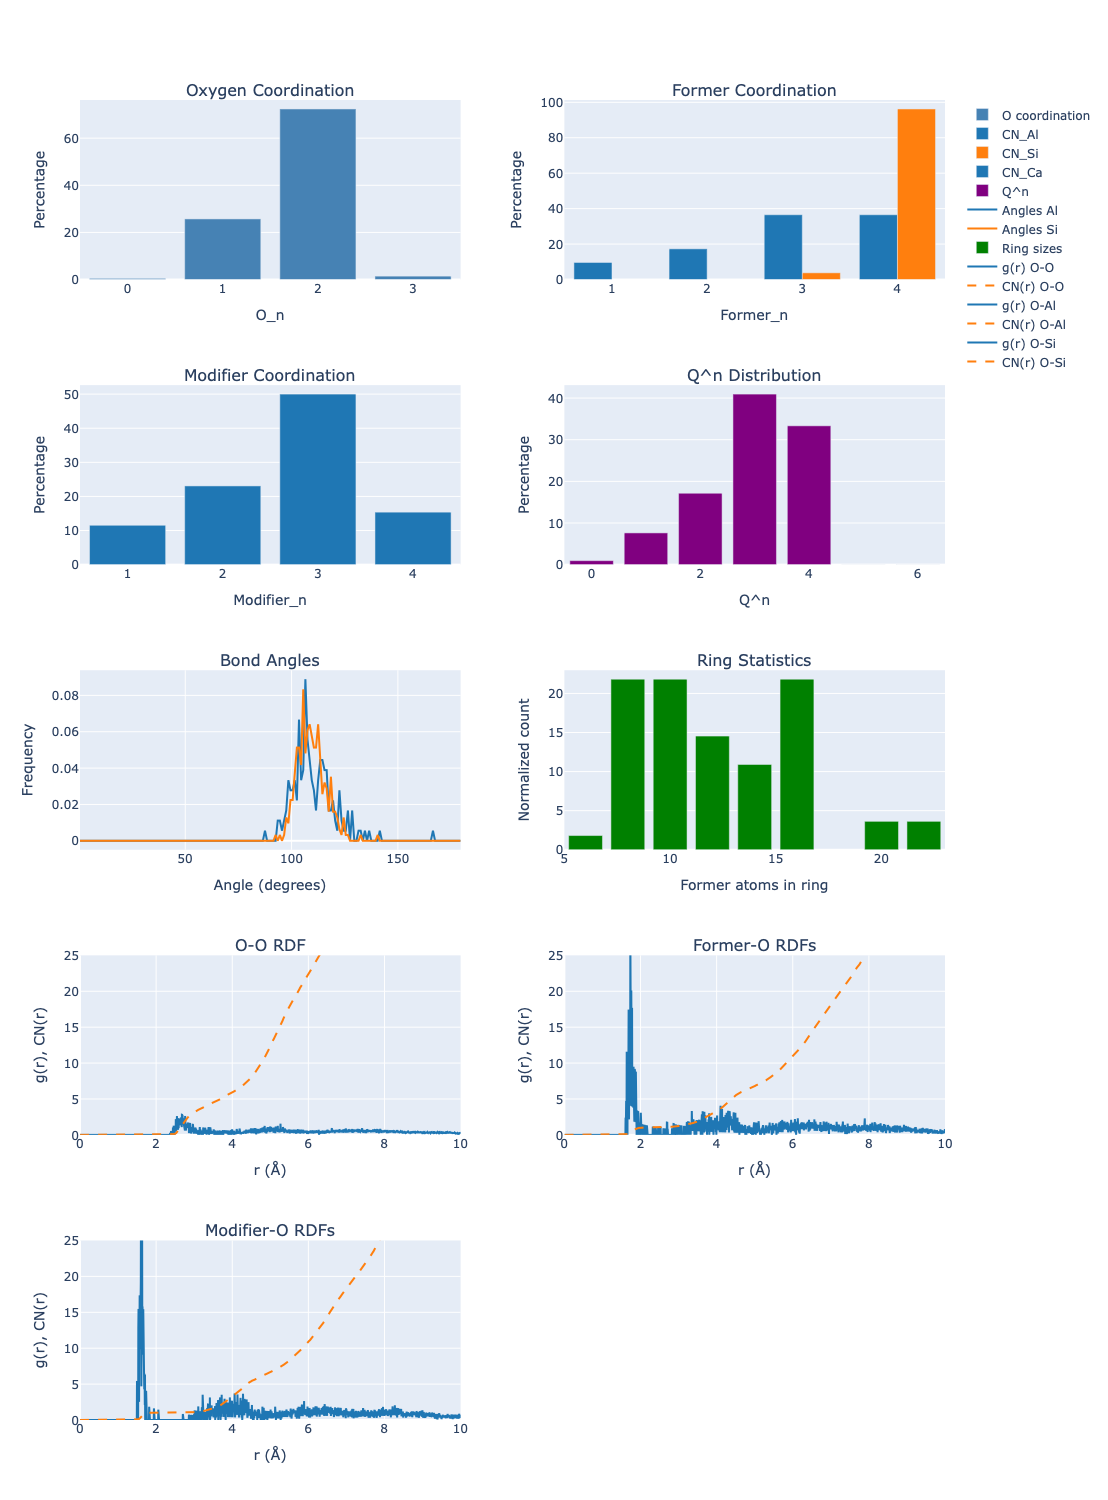

In [8]:
fig = plot_analysis_results_plotly(results_analysis)
fig.show()

In [9]:
# Explore the structured analysis results
print("=== Structural Analysis Results ===")
print(f"Density: {results_analysis.density:.2f} g/cm³")

print("\n=== Coordination Information ===")
if results_analysis.coordination.oxygen:
    print("Oxygen coordination:", results_analysis.coordination.oxygen)

print("\n=== Network Information ===")
print(f"Network connectivity: {results_analysis.network.connectivity:.3f}")
if results_analysis.network.Qn_distribution:
    print("Q^n distribution:", results_analysis.network.Qn_distribution)

print("\n=== Element Classification ===")
print("Network formers:", results_analysis.elements.formers)
print("Modifiers:", results_analysis.elements.modifiers)
print("Cutoff distances:", results_analysis.elements.cutoffs)

=== Structural Analysis Results ===
Density: 2.84 g/cm³

=== Coordination Information ===
Oxygen coordination: {'0': 1, '1': 54, '2': 152, '3': 3}

=== Network Information ===
Network connectivity: 2.981
Q^n distribution: {'0': 1.0, '1': 8.0, '2': 18.0, '3': 43.0, '4': 35.0, '5': 0.0, '6': 0.0}

=== Element Classification ===
Network formers: ['Al', 'Si']
Modifiers: ['Ca']
Cutoff distances: {'O': 1.8225, 'Al': 1.8225, 'Si': 1.7825000000000002, 'Ca': 2.4725}
